# Retail Banking Credit Risk & Customer Analytics
### Python Analysis | Cleaning, Feature Engineering, EDA & Validation

**Portfolio project · Retail Banking / Credit Risk · UCI Default of Credit Card Clients**

This notebook is the reproducible Python layer of the project. The project includes a bundled raw CSV for reproducibility. Python independently re-runs data quality checks, feature engineering, business analysis, and cross-tool control-total validation before the SQL and Power BI layers.

**Business question**

> Which customer and repayment characteristics are associated with higher observed default risk, where is credit exposure concentrated, and what signals could support portfolio monitoring and collections analysis?

**Scope:** one historical customer-level record with six periods of repayment status, bill amounts and payment amounts. The target is `default payment next month`.

**Important limitation:** the source is a historical public credit-card dataset from Taiwan. The analysis is a case-study implementation for portfolio analytics; it is not a live-bank portfolio, an underwriting policy, or evidence of causality.

## Project context

### Stakeholders
| Stakeholder | Analytical need |
|---|---|
| Credit Risk Manager | Understand observed default patterns and exposure by segment |
| Collections Manager | Identify repayment-stress signals for monitoring |
| Operations Manager | Track portfolio KPIs and data-quality issues |
| Senior Management | See portfolio scale, risk and major findings |

### Project pipeline

**Business framing → Excel → Python → SQL/MySQL → Power BI → Cross-tool validation → Insights & recommendations → Portfolio packaging**

Excel is the fast inspection layer. Python is the reproducible cleaning, feature engineering and EDA layer. SQL will independently reproduce and extend the analysis; Power BI will become the reporting and semantic-model layer.

## 1. Business questions

Eight primary questions frame the analysis:

1. **Portfolio health:** What is the overall customer volume and observed default rate?
2. **Risk concentration:** Where is recorded credit exposure concentrated, and how does observed default rate vary by credit-limit segment?
3. **Customer profile:** How does observed default rate vary across age and profile dimensions?
4. **Repayment behavior:** Which repayment-status patterns are associated with different observed default rates?
5. **Utilization & delinquency:** How do utilization and repeated delayed-payment periods differ across outcomes?
6. **Payment capacity proxy:** How does payment-to-bill behavior differ across outcomes and payment-status groups?
7. **Monthly behavior:** What changes across the six observed periods in bills, payments, delay rates and coverage?
8. **Monitoring context:** Which combinations of exposure and repayment stress are useful for analytical review, and what limitations apply?


## 2. Load & profile

The supplied CSV contains an export-style first row (`X1` … `X23`, `Y`) followed by the actual business header and 30,000 customer records. Loading with `header=1` retains the real source field names used throughout the project.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)

PROJECT_NAME = "Retail Banking Credit Risk & Customer Analytics"
TARGET = "default payment next month"
ID_COL = "ID"
FILE_NAME = "default of credit card clients.csv"

# Resolve the project input without depending on the notebook launch directory.
search_paths = []
for base in [Path.cwd(), *Path.cwd().parents]:
    search_paths.extend([
        base / "data" / "raw" / FILE_NAME,
        base / FILE_NAME,
    ])

RAW_PATH = next((p.resolve() for p in search_paths if p.exists()), None)

if RAW_PATH is None:
    raise FileNotFoundError(
        f"Could not locate '{FILE_NAME}'. "
        f"Expected it in the project's data/raw folder."
    )

print(PROJECT_NAME)
print("Dataset:", RAW_PATH)

Retail Banking Credit Risk & Customer Analytics
Dataset: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/raw/default of credit card clients.csv


In [2]:
# Load the business header from the second physical CSV row.
df_raw = pd.read_csv(RAW_PATH, header=1)

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
print("Fields:", df_raw.columns.tolist())
display(df_raw.head())

Rows: 30,000
Columns: 25
Fields: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

field_groups = pd.DataFrame({
    "Field Group": ["Customer profile", "Repayment status", "Bills", "Payments", "Outcome"],
    "Fields": [
        "ID, LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE",
        ", ".join(pay_status_cols),
        "BILL_AMT1 ... BILL_AMT6",
        "PAY_AMT1 ... PAY_AMT6",
        TARGET
    ]
})
display(field_groups)

,Field Group,Fields
0,Customer profile,"ID, LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE"
1,Repayment status,"PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6"
2,Bills,BILL_AMT1 ... BILL_AMT6
3,Payments,PAY_AMT1 ... PAY_AMT6
4,Outcome,default payment next month


## Source codebook summary

The source documentation defines the principal profile and repayment codes. The raw numeric values stay intact; these labels are analytical references only.

| Field | Source-documented interpretation | Observed handling in this project |
|---|---|---|
| `SEX` | 1 = male; 2 = female | Retained as numeric code |
| `EDUCATION` | 1 = graduate school; 2 = university; 3 = high school; 4 = others | Observed 0/5/6 are retained and audited separately |
| `MARRIAGE` | 1 = married; 2 = single; 3 = others | Observed 0 is retained and audited separately |
| `PAY_*` | -1 = pay duly; positive codes represent increasing months of payment delay | Positive codes drive the delayed-period flag; other observed codes are retained without guessed labels |
| `default payment next month` | 0 = no default; 1 = default | Binary outcome used throughout |

The analysis treats undocumented/extra observed codes as a data-quality consideration rather than silently merging them into a documented category.


In [4]:
# Observed codes vs the source-documented core categories
codebook_audit = pd.DataFrame({
    "Field": ["SEX", "EDUCATION", "MARRIAGE"],
    "Observed values": [
        sorted(df_raw["SEX"].unique().tolist()),
        sorted(df_raw["EDUCATION"].unique().tolist()),
        sorted(df_raw["MARRIAGE"].unique().tolist())
    ],
    "Documented core values": [
        [1, 2], [1, 2, 3, 4], [1, 2, 3]
    ]
})
display(codebook_audit)


,Field,Observed values,Documented core values
0,SEX,"[1, 2]","[1, 2]"
1,EDUCATION,"[0, 1, 2, 3, 4, 5, 6]","[1, 2, 3, 4]"
2,MARRIAGE,"[0, 1, 2, 3]","[1, 2, 3]"


In [5]:
portfolio_profile = pd.DataFrame({
    "Metric": [
        "Customer records", "Fields", "Missing values", "Duplicate rows",
        "Unique customer IDs", "Duplicate IDs", "Defaulted customers",
        "Non-defaulted customers", "Observed default rate"
    ],
    "Value": [
        len(df_raw), df_raw.shape[1], int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()), int(df_raw[ID_COL].nunique()),
        int(df_raw[ID_COL].duplicated().sum()), int((df_raw[TARGET] == 1).sum()),
        int((df_raw[TARGET] == 0).sum()), df_raw[TARGET].mean()
    ]
})
display(portfolio_profile)

,Metric,Value
0,Customer records,"30,000.0000"
1,Fields,25.0000
2,Missing values,0.0000
3,Duplicate rows,0.0000
4,Unique customer IDs,"30,000.0000"
5,Duplicate IDs,0.0000
6,Defaulted customers,"6,636.0000"
7,Non-defaulted customers,"23,364.0000"
8,Observed default rate,0.2212


### Profile takeaway

The raw extract contains 30,000 customer records with the intended one-row-per-customer grain. These totals become the control figures for the rest of the notebook.


## Profile takeaway

The raw source is one row per customer. The target is binary, and the initial profile is used as the control total for every later stage.

## 3. Data quality assessment

The quality review focuses on conditions that can alter a business conclusion: missingness, duplicate records, coded values, repayment-status values, numeric ranges and ratio denominators.

In [6]:
missing_summary = df_raw.isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df_raw)
display(missing_summary.sort_values("missing_count", ascending=False))

,missing_count,missing_pct
ID,0,0.0000
LIMIT_BAL,0,0.0000
SEX,0,0.0000
EDUCATION,0,0.0000
MARRIAGE,0,0.0000
AGE,0,0.0000
PAY_0,0,0.0000
PAY_2,0,0.0000
PAY_3,0,0.0000
PAY_4,0,0.0000


In [7]:
duplicate_summary = pd.DataFrame({
    "Check": ["Exact duplicate rows", "Duplicate IDs", "Unique IDs", "Rows"],
    "Result": [
        int(df_raw.duplicated().sum()),
        int(df_raw[ID_COL].duplicated().sum()),
        int(df_raw[ID_COL].nunique()),
        len(df_raw)
    ]
})
display(duplicate_summary)

,Check,Result
0,Exact duplicate rows,0
1,Duplicate IDs,0
2,Unique IDs,30000
3,Rows,30000


In [8]:
# Numeric range review
range_rows=[]
for col in ["AGE", "LIMIT_BAL"]:
    range_rows.append({
        "Field": col,
        "Min": df_raw[col].min(),
        "Max": df_raw[col].max(),
        "Zero": int((df_raw[col] == 0).sum()),
        "Negative": int((df_raw[col] < 0).sum())
    })
display(pd.DataFrame(range_rows))

# Distribution / skewness review for the main amount fields.
distribution_review = pd.DataFrame({
    "Field": ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"],
    "Median": [df_raw[c].median() for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]],
    "P75": [df_raw[c].quantile(.75) for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]],
    "P95": [df_raw[c].quantile(.95) for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]],
    "P99": [df_raw[c].quantile(.99) for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]],
    "Max": [df_raw[c].max() for c in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]]
})
display(distribution_review)

,Field,Min,Max,Zero,Negative
0,AGE,21,79,0,0
1,LIMIT_BAL,10000,1000000,0,0


,Field,Median,P75,P95,P99,Max
0,LIMIT_BAL,"140,000.0000","240,000.0000","430,000.0000","500,000.0000",1000000
1,BILL_AMT1,"22,381.5000","67,091.0000","201,203.0500","350,110.6800",964511
2,PAY_AMT1,"2,100.0000","5,006.0000","18,428.2000","66,522.1800",873552


In [9]:
# Target and category audit
target_distribution = df_raw[TARGET].value_counts(dropna=False).sort_index().rename("count").to_frame()
display(target_distribution)

for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"\n{col}")
    display(df_raw[col].value_counts(dropna=False).sort_index().rename("count").to_frame())

,count
default payment next month,
0,23364
1,6636



SEX


,count
SEX,
1,11888
2,18112



EDUCATION


,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51



MARRIAGE


,count
MARRIAGE,
0,54
1,13659
2,15964
3,323


In [10]:
# Repayment-status distributions
for col in pay_status_cols:
    print(f"\n{col}")
    display(df_raw[col].value_counts(dropna=False).sort_index().rename("count").to_frame())


PAY_0


,count
PAY_0,
-2,2759
-1,5686
0,14737
1,3688
2,2667
3,322
4,76
5,26
6,11



PAY_2


,count
PAY_2,
-2,3782
-1,6050
0,15730
1,28
2,3927
3,326
4,99
5,25
6,12



PAY_3


...

,count
PAY_4,
-2,4348
-1,5687
0,16455
1,2
2,3159
3,180
4,69
5,35
6,5



PAY_5


,count
PAY_5,
-2,4546
-1,5539
0,16947
2,2626
3,178
4,84
5,17
6,4
7,58



PAY_6


,count
PAY_6,
-2,4895
-1,5740
0,16286
2,2766
3,184
4,49
5,13
6,19
7,46


In [11]:
# Amount-field exceptions
amount_quality=[]
for col in bill_cols + payment_cols:
    amount_quality.append({
        "Field": col,
        "Negative": int((df_raw[col] < 0).sum()),
        "Zero": int((df_raw[col] == 0).sum()),
        "Min": df_raw[col].min(),
        "Max": df_raw[col].max()
    })
display(pd.DataFrame(amount_quality))

,Field,Negative,Zero,Min,Max
0,BILL_AMT1,590,2008,-165580,964511
1,BILL_AMT2,669,2506,-69777,983931
2,BILL_AMT3,655,2870,-157264,1664089
3,BILL_AMT4,675,3195,-170000,891586
4,BILL_AMT5,655,3506,-81334,927171
5,BILL_AMT6,688,4020,-339603,961664
6,PAY_AMT1,0,5249,0,873552
7,PAY_AMT2,0,5396,0,1684259
8,PAY_AMT3,0,5968,0,896040
9,PAY_AMT4,0,6408,0,621000


### Quality takeaway

There is no missingness or duplicate-customer problem in the source extract. The main analytical quality considerations are coded categories, special repayment-status values and non-positive bill denominators.


### Quality decisions captured in the analytical design

- Missing and duplicate counts are measured rather than assumed.
- `EDUCATION` and `MARRIAGE` retain observed codes that fall outside the documented core categories; no silent relabeling is applied.
- `PAY_*` source codes remain numeric. A positive status code is used only for the documented analytical **delayed-period flag**; special negative/zero codes are not given guessed meanings.
- Bill/payment amounts remain in the data even when zero or negative. Ratio calculations explicitly control the denominator.
- Extreme amount values are profiled and retained rather than automatically removed.

## 4. Analytical preparation

A separate analytical copy protects the raw extract and keeps transformations reproducible.

In [12]:
df = df_raw.copy()
numeric_cols = [ID_COL, "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", TARGET] + pay_status_cols + bill_cols + payment_cols
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

assert len(df) == len(df_raw)
print("Analytical frame:", df.shape)

Analytical frame: (30000, 25)


## 5. Feature engineering

The feature set mirrors the business definitions used in Excel and is designed to carry forward cleanly into SQL and Power BI.

In [13]:
# Six-month averages
df["Avg_Bill_6M"] = df[bill_cols].mean(axis=1)
df["Avg_Payment_6M"] = df[payment_cols].mean(axis=1)

# Latest-month utilization: September 2005 in the source layout.
df["Credit_Utilization"] = np.where(
    df["LIMIT_BAL"] > 0,
    df["BILL_AMT1"] / df["LIMIT_BAL"],
    np.nan
)

# Ratio is defined only for positive bills.
df["Payment_to_Bill_Ratio_Valid"] = np.where(
    df["BILL_AMT1"] > 0,
    df["PAY_AMT1"] / df["BILL_AMT1"],
    np.nan
)

# Latest-month bill/payment status.
df["Bill_Amount_Status"] = np.select(
    [df["BILL_AMT1"] < 0, df["BILL_AMT1"] == 0, df["BILL_AMT1"] > 0],
    ["Negative Bill", "Zero Bill", "Positive Bill"],
    default="Unknown"
)

df["Payment_vs_Bill_Status"] = np.select(
    [
        df["BILL_AMT1"] <= 0,
        df["PAY_AMT1"] < 0,
        df["PAY_AMT1"] == 0,
        df["PAY_AMT1"] < df["BILL_AMT1"],
        df["PAY_AMT1"] == df["BILL_AMT1"],
        df["PAY_AMT1"] > df["BILL_AMT1"]
    ],
    [
        "Bill Not Positive", "Negative Payment", "No Payment",
        "Payment Below Bill", "Payment Equals Bill", "Payment Above Bill"
    ],
    default="Unknown"
)

# Repeated delayed periods: positive repayment-status code.
for col in pay_status_cols:
    df[f"{col}_Delayed"] = (df[col] > 0).astype(int)

delay_cols = [f"{col}_Delayed" for col in pay_status_cols]
df["Delinquency_Count"] = df[delay_cols].sum(axis=1)
df["Max_Delinquency_Code"] = df[pay_status_cols].max(axis=1)
df["Default_Label"] = np.where(df[TARGET] == 1, "Default", "No Default")

In [14]:
# Business-friendly segments
df["Age_Group"] = np.select(
    [df["AGE"] < 25, df["AGE"] < 35, df["AGE"] < 45, df["AGE"] < 55],
    ["<25", "25-34", "35-44", "45-54"],
    default="55+"
)

df["Credit_Limit_Band"] = np.select(
    [
        df["LIMIT_BAL"] < 50000,
        df["LIMIT_BAL"] < 100000,
        df["LIMIT_BAL"] < 200000,
        df["LIMIT_BAL"] < 500000
    ],
    ["<50K", "50K-99K", "100K-199K", "200K-499K"],
    default="500K+"
)

df["Utilization_Band"] = np.select(
    [
        df["Credit_Utilization"] < 0.25,
        df["Credit_Utilization"] < 0.50,
        df["Credit_Utilization"] < 0.75,
        df["Credit_Utilization"] <= 1.00
    ],
    ["<25%", "25-49%", "50-74%", "75-100%"],
    default=">100%"
)

feature_quality = pd.DataFrame({
    "Metric": [
        "Rows after feature engineering",
        "Customers with delinquency",
        "Non-positive latest bills",
        "Valid latest payment-to-bill ratios",
        "Average 6M bill",
        "Average 6M payment",
        "Average latest-month utilization"
    ],
    "Value": [
        len(df),
        int((df["Delinquency_Count"] > 0).sum()),
        int((df["BILL_AMT1"] <= 0).sum()),
        int(df["Payment_to_Bill_Ratio_Valid"].notna().sum()),
        df["Avg_Bill_6M"].mean(),
        df["Avg_Payment_6M"].mean(),
        df["Credit_Utilization"].mean()
    ]
})
display(feature_quality)

,Metric,Value
0,Rows after feature engineering,"30,000.0000"
1,Customers with delinquency,"10,069.0000"
2,Non-positive latest bills,"2,598.0000"
3,Valid latest payment-to-bill ratios,"27,402.0000"
4,Average 6M bill,"44,976.9452"
5,Average 6M payment,"5,275.2321"
6,Average latest-month utilization,0.4238


### Feature takeaway

The analytical frame preserves the 30,000-customer grain while adding consistent measures for utilization, payment behavior and repayment stress.


## 6. Exploratory analysis

The EDA is deliberately question-led. Counts are shown beside rates so that small groups are not mistaken for strong portfolio-wide signals.

In [15]:
def default_rate_table(data, group_col):
    return (
        data.groupby(group_col, observed=False)
            .agg(
                Customers=(ID_COL, "nunique"),
                Defaulted=(TARGET, "sum"),
                Observed_Default_Rate=(TARGET, "mean")
            )
            .reset_index()
    )

def pct(x):
    return f"{x:.2%}"

portfolio_kpis = pd.DataFrame({
    "Metric": [
        "Total customers", "Defaulted customers", "Observed default rate",
        "Total credit limit", "Average credit limit", "Average 6M bill",
        "Average 6M payment", "Customers with delinquency", "Delinquency rate"
    ],
    "Value": [
        df[ID_COL].nunique(), int(df[TARGET].sum()), df[TARGET].mean(),
        df["LIMIT_BAL"].sum(), df["LIMIT_BAL"].mean(), df["Avg_Bill_6M"].mean(),
        df["Avg_Payment_6M"].mean(), int((df["Delinquency_Count"] > 0).sum()),
        (df["Delinquency_Count"] > 0).mean()
    ]
})
display(portfolio_kpis)

,Metric,Value
0,Total customers,"30,000.0000"
1,Defaulted customers,"6,636.0000"
2,Observed default rate,0.2212
3,Total credit limit,"5,024,529,680.0000"
4,Average credit limit,"167,484.3227"
5,Average 6M bill,"44,976.9452"
6,Average 6M payment,"5,275.2321"
7,Customers with delinquency,"10,069.0000"
8,Delinquency rate,0.3356


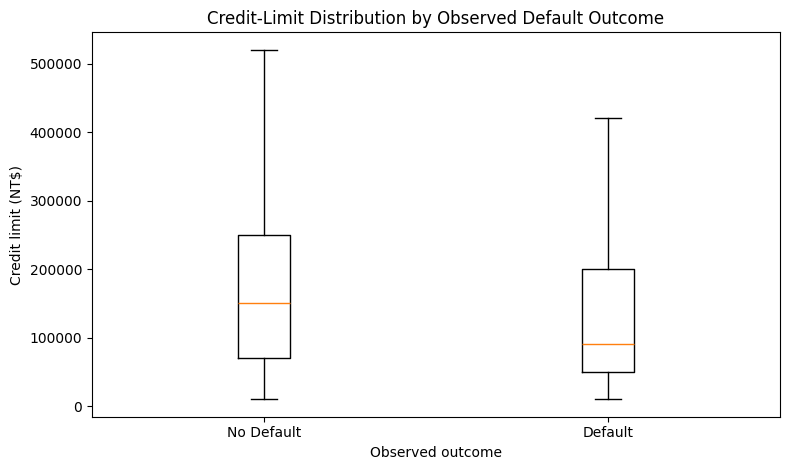

In [16]:
# 1. Credit-limit distribution by observed default outcome
fig, ax = plt.subplots(figsize=(8, 4.8))
data_to_plot = [
    df.loc[df[TARGET] == 0, "LIMIT_BAL"],
    df.loc[df[TARGET] == 1, "LIMIT_BAL"]
]
ax.boxplot(data_to_plot, tick_labels=["No Default", "Default"], showfliers=False)
ax.set_title("Credit-Limit Distribution by Observed Default Outcome")
ax.set_xlabel("Observed outcome")
ax.set_ylabel("Credit limit (NT$)")
plt.tight_layout()
plt.show()

,Credit_Limit_Band,Customers,Defaulted,Observed_Default_Rate,Total_Credit_Limit,Exposure_Share
4,<50K,4311,1555,0.3607,101982000,0.0203
3,50K-99K,7139,1857,0.2601,452870000,0.0901
0,100K-199K,7400,1537,0.2077,1046820000,0.2083
1,200K-499K,10222,1583,0.1549,2938587680,0.5848
2,500K+,928,104,0.1121,484270000,0.0964


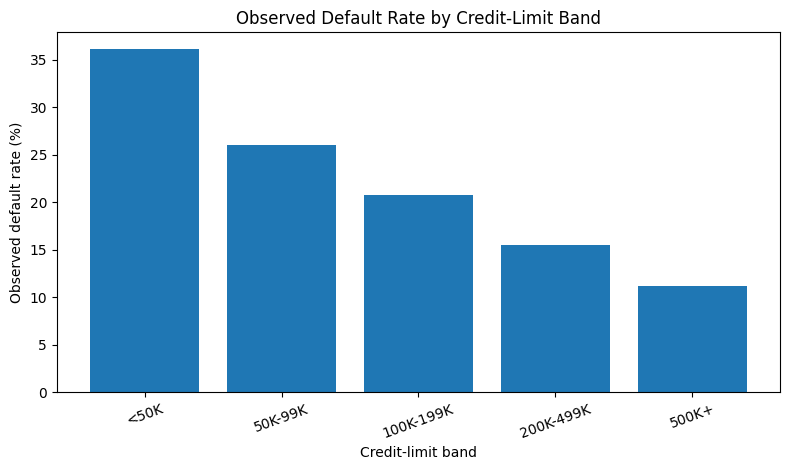

In [17]:
# 2. Credit-limit bands: risk and exposure
credit_order = ["<50K", "50K-99K", "100K-199K", "200K-499K", "500K+"]
credit_band = default_rate_table(df, "Credit_Limit_Band")
credit_band["Credit_Limit_Band"] = pd.Categorical(credit_band["Credit_Limit_Band"], categories=credit_order, ordered=True)
credit_band = credit_band.sort_values("Credit_Limit_Band")
credit_band["Total_Credit_Limit"] = [
    df.loc[df["Credit_Limit_Band"] == b, "LIMIT_BAL"].sum() for b in credit_band["Credit_Limit_Band"]
]
credit_band["Exposure_Share"] = credit_band["Total_Credit_Limit"] / df["LIMIT_BAL"].sum()
display(credit_band)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(credit_band["Credit_Limit_Band"].astype(str), credit_band["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Credit-Limit Band")
ax.set_xlabel("Credit-limit band")
ax.set_ylabel("Observed default rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

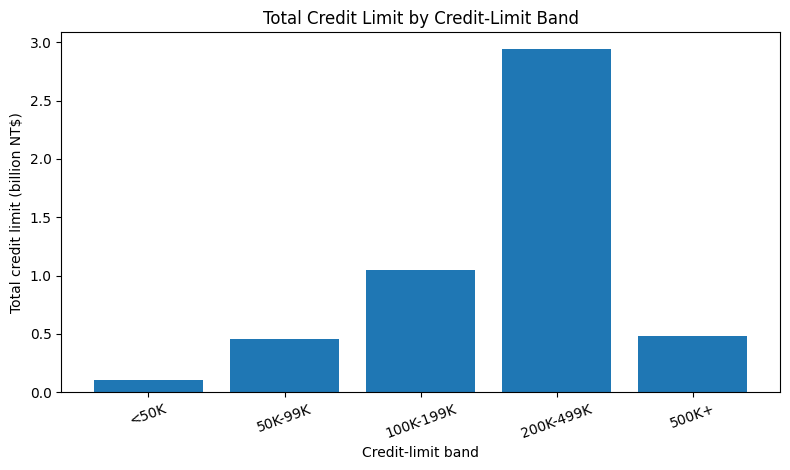

In [18]:
# 3. Exposure concentration
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(credit_band["Credit_Limit_Band"].astype(str), credit_band["Total_Credit_Limit"] / 1e9)
ax.set_title("Total Credit Limit by Credit-Limit Band")
ax.set_xlabel("Credit-limit band")
ax.set_ylabel("Total credit limit (billion NT$)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,Age_Group,Customers,Defaulted,Observed_Default_Rate
4,<25,2685,730,0.2719
0,25-34,13011,2641,0.2030
1,35-44,9018,1971,0.2186
2,45-54,4233,1013,0.2393
3,55+,1053,281,0.2669


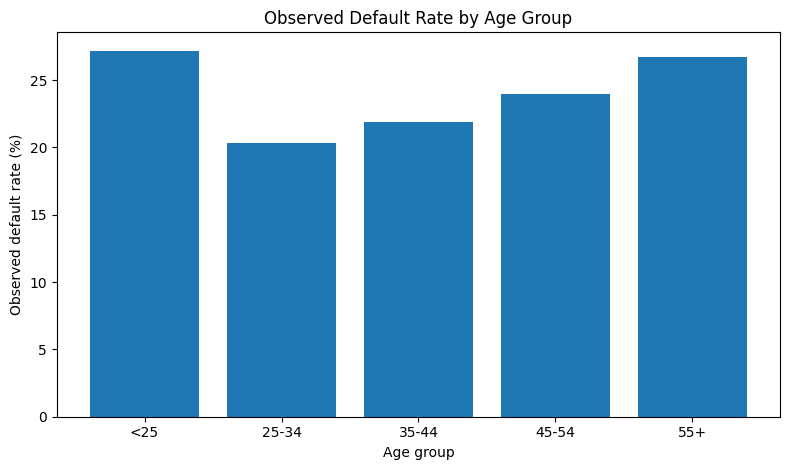

In [19]:
# 4. Age profile
age_order = ["<25", "25-34", "35-44", "45-54", "55+"]
age_band = default_rate_table(df, "Age_Group")
age_band["Age_Group"] = pd.Categorical(age_band["Age_Group"], categories=age_order, ordered=True)
age_band = age_band.sort_values("Age_Group")
display(age_band)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(age_band["Age_Group"].astype(str), age_band["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,PAY_0,Customers,Defaulted,Observed_Default_Rate
0,-2,2759,365,0.1323
1,-1,5686,954,0.1678
2,0,14737,1888,0.1281
3,1,3688,1252,0.3395
4,2,2667,1844,0.6914
5,3,322,244,0.7578
6,4,76,52,0.6842
7,5,26,13,0.5000
8,6,11,6,0.5455
9,7,9,7,0.7778


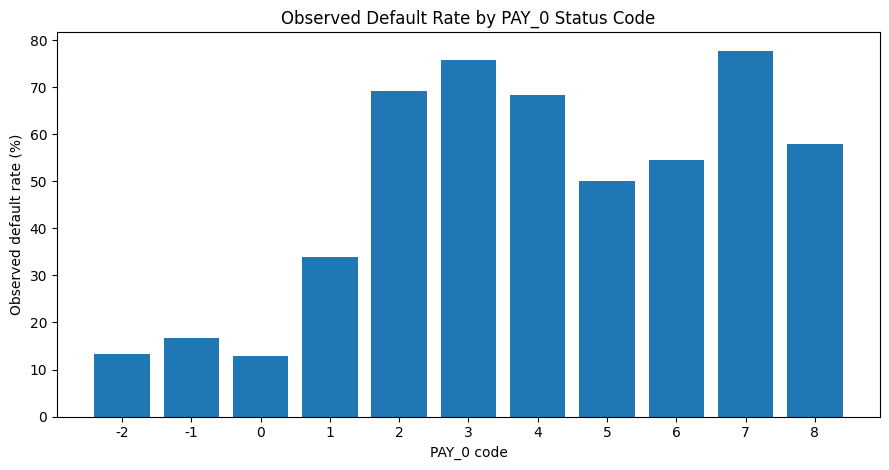

In [20]:
# 5. Repayment status
pay0 = default_rate_table(df, "PAY_0").sort_values("PAY_0")
display(pay0)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(pay0["PAY_0"].astype(str), pay0["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by PAY_0 Status Code")
ax.set_xlabel("PAY_0 code")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,Utilization_Band,Customers,Defaulted,Observed_Default_Rate
3,<25%,14037,2566,0.1828
0,25-49%,3589,780,0.2173
1,50-74%,3579,929,0.2596
2,75-100%,6680,1725,0.2582
4,>100%,2115,636,0.3007


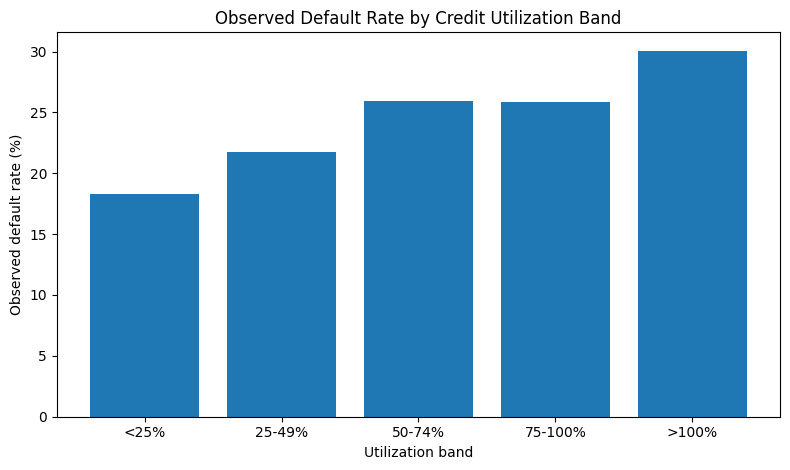

In [21]:
# 6. Utilization
util_order = ["<25%", "25-49%", "50-74%", "75-100%", ">100%"]
util_band = default_rate_table(df, "Utilization_Band")
util_band["Utilization_Band"] = pd.Categorical(util_band["Utilization_Band"], categories=util_order, ordered=True)
util_band = util_band.sort_values("Utilization_Band")
display(util_band)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(util_band["Utilization_Band"].astype(str), util_band["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Credit Utilization Band")
ax.set_xlabel("Utilization band")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,Delinquency_Count,Customers,Defaulted,Observed_Default_Rate
0,0,19931,2334,0.1171
1,1,4426,1320,0.2982
2,2,1899,736,0.3876
3,3,1154,587,0.5087
4,4,951,545,0.5731
5,5,298,171,0.5738
6,6,1341,943,0.7032


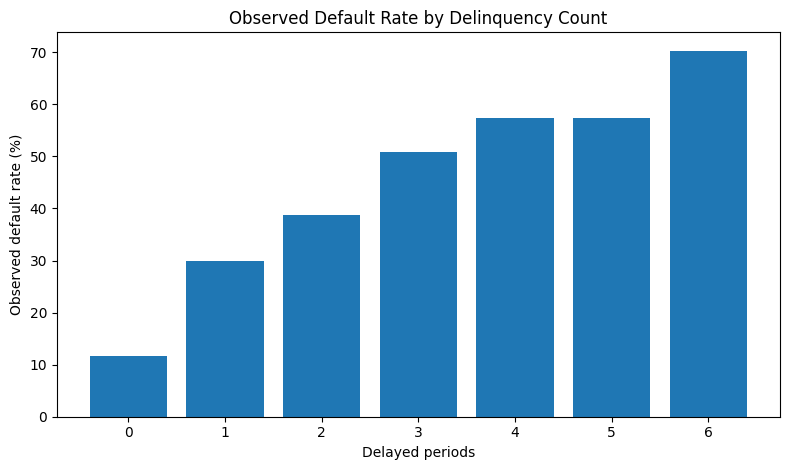

In [22]:
# 7. Delinquency count
delinq = default_rate_table(df, "Delinquency_Count").sort_values("Delinquency_Count")
display(delinq)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(delinq["Delinquency_Count"].astype(str), delinq["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Delinquency Count")
ax.set_xlabel("Delayed periods")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,Default_Label,Customers,Avg_Bill_6M,Median_Bill_6M,Avg_Payment_6M,Median_Payment_6M,Avg_Utilization,Median_Utilization
0,Default,6636,"43,470.4926","19,781.3333","3,328.2156","1,612.4167",0.4903,0.4929
1,No Default,23364,"45,404.8180","21,443.4167","5,828.2368","2,754.0000",0.4049,0.2675


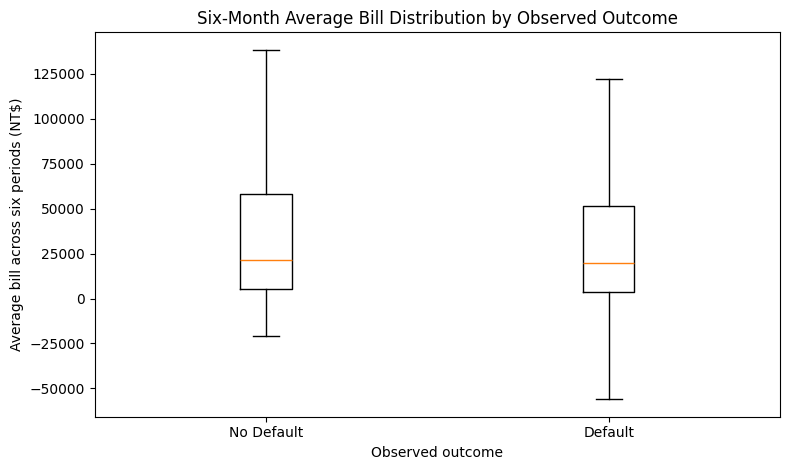

In [23]:
# 8. Bill and payment context by observed outcome
behavior = (
    df.groupby("Default_Label")
      .agg(
          Customers=(ID_COL, "nunique"),
          Avg_Bill_6M=("Avg_Bill_6M", "mean"),
          Median_Bill_6M=("Avg_Bill_6M", "median"),
          Avg_Payment_6M=("Avg_Payment_6M", "mean"),
          Median_Payment_6M=("Avg_Payment_6M", "median"),
          Avg_Utilization=("Credit_Utilization", "mean"),
          Median_Utilization=("Credit_Utilization", "median")
      )
      .reset_index()
)
display(behavior)

fig, ax = plt.subplots(figsize=(8, 4.8))
bill_plot = [
    df.loc[df["Default_Label"] == "No Default", "Avg_Bill_6M"],
    df.loc[df["Default_Label"] == "Default", "Avg_Bill_6M"]
]
ax.boxplot(bill_plot, tick_labels=["No Default", "Default"], showfliers=False)
ax.set_title("Six-Month Average Bill Distribution by Observed Outcome")
ax.set_xlabel("Observed outcome")
ax.set_ylabel("Average bill across six periods (NT$)")
plt.tight_layout()
plt.show()


,Default_Label,Customers,Mean_Ratio,Median_Ratio,P25,P75
0,Default,5993,0.8804,0.0503,0.0153,0.1439
1,No Default,21409,2.0268,0.0658,0.0387,0.3373


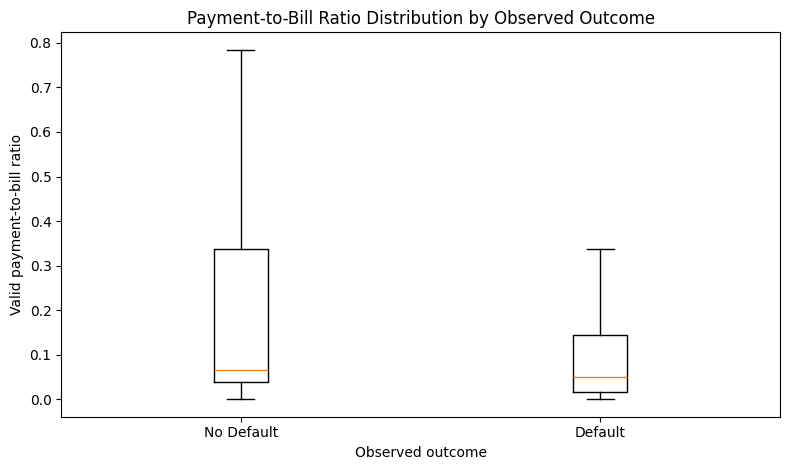

In [24]:
# 9. Numeric payment-to-bill ratio distribution by outcome
positive_bill = df[df["BILL_AMT1"] > 0].copy()
ratio_summary = (
    positive_bill.groupby("Default_Label")["Payment_to_Bill_Ratio_Valid"]
                 .agg(["count", "mean", "median", lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
                 .reset_index()
)
ratio_summary.columns = ["Default_Label", "Customers", "Mean_Ratio", "Median_Ratio", "P25", "P75"]
display(ratio_summary)

fig, ax = plt.subplots(figsize=(8, 4.8))
ratio_plot = [
    positive_bill.loc[positive_bill["Default_Label"] == "No Default", "Payment_to_Bill_Ratio_Valid"],
    positive_bill.loc[positive_bill["Default_Label"] == "Default", "Payment_to_Bill_Ratio_Valid"]
]
ax.boxplot(ratio_plot,  tick_labels=["No Default", "Default"], showfliers=False)
ax.set_title("Payment-to-Bill Ratio Distribution by Observed Outcome")
ax.set_xlabel("Observed outcome")
ax.set_ylabel("Valid payment-to-bill ratio")
plt.tight_layout()
plt.show()

,Payment_vs_Bill_Status,Customers,Defaulted,Observed_Default_Rate
0,No Payment,3495,1390,0.3977
2,Payment Below Bill,20036,4003,0.1998
3,Payment Equals Bill,671,158,0.2355
1,Payment Above Bill,3200,442,0.1381


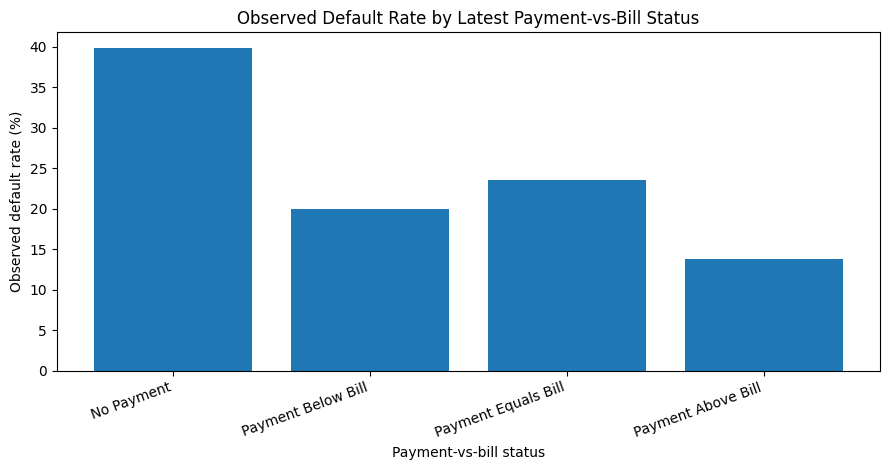

In [25]:
# 10. Payment-vs-bill status among positive-bill customers
payment_behavior = default_rate_table(positive_bill, "Payment_vs_Bill_Status")
status_order = ["No Payment", "Payment Below Bill", "Payment Equals Bill", "Payment Above Bill"]
payment_behavior["Payment_vs_Bill_Status"] = pd.Categorical(payment_behavior["Payment_vs_Bill_Status"], categories=status_order, ordered=True)
payment_behavior = payment_behavior.sort_values("Payment_vs_Bill_Status")
display(payment_behavior)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(payment_behavior["Payment_vs_Bill_Status"].astype(str), payment_behavior["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Latest Payment-vs-Bill Status")
ax.set_xlabel("Payment-vs-bill status")
ax.set_ylabel("Observed default rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,EDUCATION,Customers,Defaulted,Observed_Default_Rate
0,0,14,0,0.0000
1,1,10585,2036,0.1923
2,2,14030,3330,0.2373
3,3,4917,1237,0.2516
4,4,123,7,0.0569
5,5,280,18,0.0643
6,6,51,8,0.1569


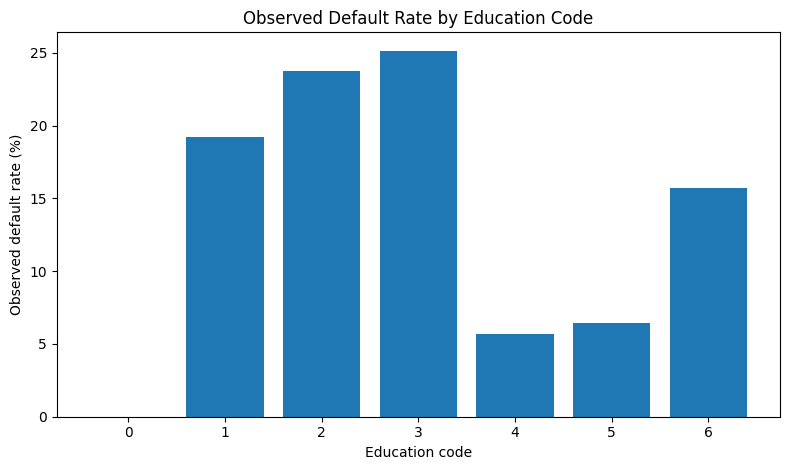

In [26]:
# 11. Education
education = default_rate_table(df, "EDUCATION").sort_values("EDUCATION")
display(education)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(education["EDUCATION"].astype(str), education["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Education Code")
ax.set_xlabel("Education code")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,MARRIAGE,Customers,Defaulted,Observed_Default_Rate
0,0,54,5,0.0926
1,1,13659,3206,0.2347
2,2,15964,3341,0.2093
3,3,323,84,0.2601


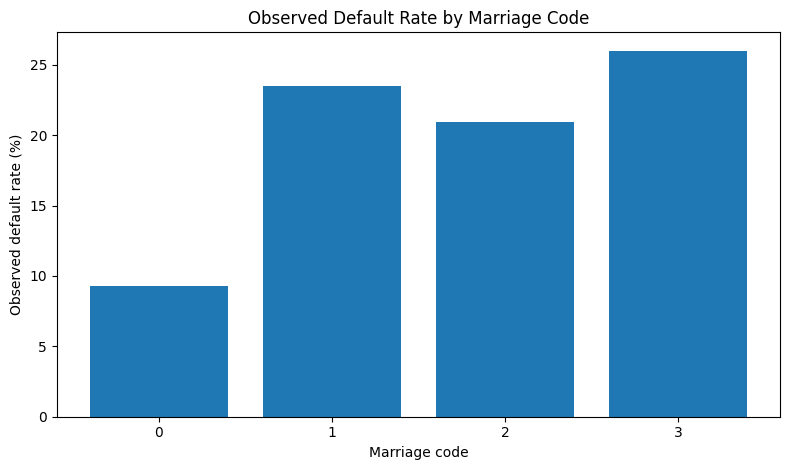

In [27]:
# 12. Marriage
marriage = default_rate_table(df, "MARRIAGE").sort_values("MARRIAGE")
display(marriage)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(marriage["MARRIAGE"].astype(str), marriage["Observed_Default_Rate"] * 100)
ax.set_title("Observed Default Rate by Marriage Code")
ax.set_xlabel("Marriage code")
ax.set_ylabel("Observed default rate (%)")
plt.tight_layout()
plt.show()

,Month,Delay_Rate,Positive_Bill_Customers,No_Payment_Customers,No_Payment_Rate,Average_Bill,Average_Payment,Total_Positive_Bill,Total_Payment,Payment_Coverage
0,Apr 2005,0.1026,25292,3469,0.1372,"46,191.2092","5,215.5026",1168268063,156465077,0.1339
1,May 2005,0.0989,25839,3546,0.1372,"46,844.4121","4,799.3876",1210412763,143981629,0.1190
2,Jun 2005,0.1170,26130,3612,0.1382,"49,712.5740","4,826.0769",1298989558,144782306,0.1115
3,Jul 2005,0.1404,26475,3396,0.1283,"53,308.9732","5,225.6815",1411355065,156770445,0.1111
4,Aug 2005,0.1479,26825,3206,0.1195,"55,030.5887","5,921.1635",1476195541,177634905,0.1203
5,Sep 2005,0.2273,27402,3495,0.1275,"56,104.7098","5,663.5805",1537381257,169907415,0.1105


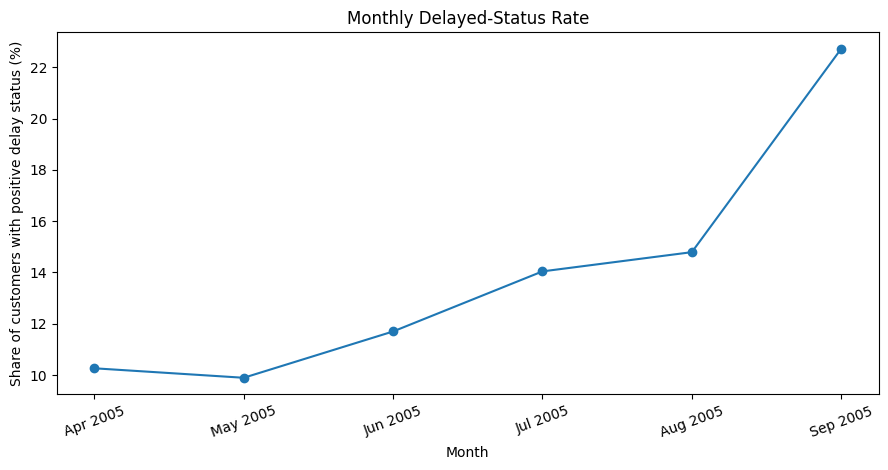

In [28]:
# 13. Monthly delay rate and payment coverage

month_map = [
    ("Apr 2005", "PAY_6", "BILL_AMT6", "PAY_AMT6"),
    ("May 2005", "PAY_5", "BILL_AMT5", "PAY_AMT5"),
    ("Jun 2005", "PAY_4", "BILL_AMT4", "PAY_AMT4"),
    ("Jul 2005", "PAY_3", "BILL_AMT3", "PAY_AMT3"),
    ("Aug 2005", "PAY_2", "BILL_AMT2", "PAY_AMT2"),
    ("Sep 2005", "PAY_0", "BILL_AMT1", "PAY_AMT1"),
]

monthly_rows = []

for month, pay_col, bill_col, payment_col in month_map:

    positive = df[df[bill_col] > 0]

    total_positive_bill = positive[bill_col].sum()
    total_payment = df[payment_col].sum()

    monthly_rows.append({
        "Month": month,

        "Delay_Rate": (df[pay_col] > 0).mean(),

        "Positive_Bill_Customers": len(positive),

        "No_Payment_Customers": int(
            (positive[payment_col] == 0).sum()
        ),

        "No_Payment_Rate": (
            positive[payment_col] == 0
        ).mean(),

        "Average_Bill": positive[bill_col].mean(),

        "Average_Payment": df[payment_col].mean(),

        "Total_Positive_Bill": total_positive_bill,

        "Total_Payment": total_payment,

        "Payment_Coverage": (
            total_payment / total_positive_bill
            if total_positive_bill != 0
            else 0
        )
    })

monthly = pd.DataFrame(monthly_rows)

display(monthly)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(
    monthly["Month"],
    monthly["Delay_Rate"] * 100,
    marker="o"
)

ax.set_title("Monthly Delayed-Status Rate")
ax.set_xlabel("Month")
ax.set_ylabel(
    "Share of customers with positive delay status (%)"
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

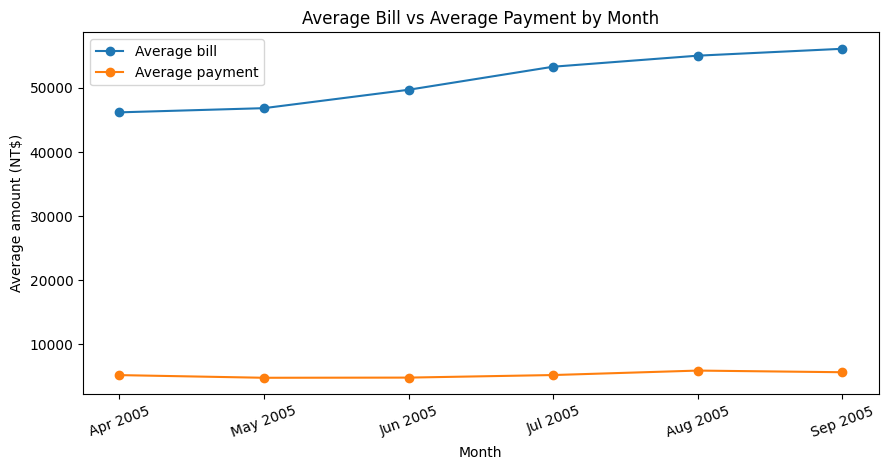

In [29]:
# 14. Monthly average bill vs average payment
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(monthly["Month"], monthly["Average_Bill"], marker="o", label="Average bill")
ax.plot(monthly["Month"], monthly["Average_Payment"], marker="o", label="Average payment")
ax.set_title("Average Bill vs Average Payment by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average amount (NT$)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

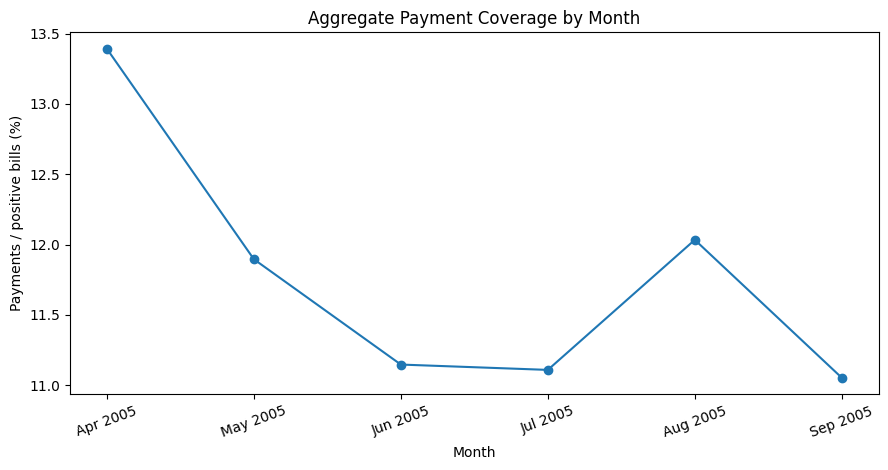

In [30]:
# 15. Payment coverage by month
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(monthly["Month"], monthly["Payment_Coverage"] * 100, marker="o")
ax.set_title("Aggregate Payment Coverage by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Payments / positive bills (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### EDA takeaway

Across the portfolio, higher observed default rates are concentrated in segments with repeated delays, higher utilization and weaker payment activity, while exposure concentration remains a separate portfolio consideration.


## Robustness and segment sensitivity

The same broad pattern should survive changes in the comparison definition. Two checks below are intentionally simple: delinquency is viewed using multiple thresholds, and payment coverage is described with both central tendency and distribution information.

In [31]:
# Delinquency threshold sensitivity
threshold_sensitivity = []
for threshold in [1, 2, 3, 4, 5, 6]:
    mask = df["Delinquency_Count"] >= threshold
    threshold_sensitivity.append({
        "Threshold": f">= {threshold} delayed periods",
        "Customers": int(mask.sum()),
        "Customer_Share": mask.mean(),
        "Observed_Default_Rate": df.loc[mask, TARGET].mean() if mask.any() else np.nan
    })

threshold_sensitivity = pd.DataFrame(threshold_sensitivity)
display(threshold_sensitivity)

,Threshold,Customers,Customer_Share,Observed_Default_Rate
0,>= 1 delayed periods,10069,0.3356,0.4273
1,>= 2 delayed periods,5643,0.1881,0.5284
2,>= 3 delayed periods,3744,0.1248,0.5999
3,>= 4 delayed periods,2590,0.0863,0.6405
4,>= 5 delayed periods,1639,0.0546,0.6797
5,>= 6 delayed periods,1341,0.0447,0.7032


In [32]:
# A compact segment evidence table for exposure + default
segment_evidence = credit_band[["Credit_Limit_Band", "Customers", "Observed_Default_Rate", "Total_Credit_Limit", "Exposure_Share"]].copy()
segment_evidence["Above_Portfolio_Default"] = segment_evidence["Observed_Default_Rate"] > df[TARGET].mean()
display(segment_evidence)

,Credit_Limit_Band,Customers,Observed_Default_Rate,Total_Credit_Limit,Exposure_Share,Above_Portfolio_Default
4,<50K,4311,0.3607,101982000,0.0203,True
3,50K-99K,7139,0.2601,452870000,0.0901,True
0,100K-199K,7400,0.2077,1046820000,0.2083,False
1,200K-499K,10222,0.1549,2938587680,0.5848,False
2,500K+,928,0.1121,484270000,0.0964,False


## Evidence-led findings

The observations below are generated from the analytical frame. They describe associations in this historical dataset; they are not causal conclusions.

In [33]:
# Generate concise, traceable findings from validated outputs.
baseline_rate = df[TARGET].mean()
low_credit = credit_band.loc[credit_band["Credit_Limit_Band"] == "<50K"].iloc[0]
high_credit = credit_band.loc[credit_band["Credit_Limit_Band"] == "500K+"].iloc[0]
zero_delinq = delinq.loc[delinq["Delinquency_Count"] == 0, "Observed_Default_Rate"].iloc[0]
six_delinq = delinq.loc[delinq["Delinquency_Count"] == 6, "Observed_Default_Rate"].iloc[0]
low_util = util_band.loc[util_band["Utilization_Band"] == "<25%", "Observed_Default_Rate"].iloc[0]
high_util = util_band.loc[util_band["Utilization_Band"] == ">100%", "Observed_Default_Rate"].iloc[0]

default_payment = behavior.loc[behavior["Default_Label"] == "Default", "Avg_Payment_6M"].iloc[0]
nodefault_payment = behavior.loc[behavior["Default_Label"] == "No Default", "Avg_Payment_6M"].iloc[0]
largest_exposure_band = credit_band.loc[credit_band["Total_Credit_Limit"].idxmax()]
no_payment_count = int(((df["BILL_AMT1"] > 0) & (df["PAY_AMT1"] == 0)).sum())
positive_bill_count = int((df["BILL_AMT1"] > 0).sum())

findings = pd.DataFrame({
    "Finding": [
        "Portfolio baseline",
        "Credit-limit pattern",
        "Delinquency pattern",
        "Utilization pattern",
        "Payment activity pattern",
        "Exposure concentration",
        "Latest-month no-payment population"
    ],
    "Evidence": [
        f"{df[ID_COL].nunique():,} customers; {baseline_rate:.2%} observed default rate.",
        f"<50K: {low_credit.Observed_Default_Rate:.2%}; 500K+: {high_credit.Observed_Default_Rate:.2%}.",
        f"0 delayed periods: {zero_delinq:.2%}; 6 delayed periods: {six_delinq:.2%}.",
        f"<25% utilization: {low_util:.2%}; >100% utilization: {high_util:.2%}.",
        f"Average 6M payment: {default_payment:,.0f} NT$ for defaulted customers vs {nodefault_payment:,.0f} NT$ for non-defaulted customers.",
        f"{largest_exposure_band.Credit_Limit_Band} holds {largest_exposure_band.Total_Credit_Limit/1e9:.2f} billion NT$ of recorded credit limit.",
        f"{no_payment_count:,} of {positive_bill_count:,} positive-bill customers made no latest-month payment ({no_payment_count/positive_bill_count:.2%})."
    ]
})
display(findings)

,Finding,Evidence
0,Portfolio baseline,"30,000 customers; 22.12% observed default rate."
1,Credit-limit pattern,<50K: 36.07%; 500K+: 11.21%.
2,Delinquency pattern,0 delayed periods: 11.71%; 6 delayed periods: ...
3,Utilization pattern,<25% utilization: 18.28%; >100% utilization: 3...
4,Payment activity pattern,"Average 6M payment: 3,328 NT$ for defaulted cu..."
5,Exposure concentration,200K-499K holds 2.94 billion NT$ of recorded c...
6,Latest-month no-payment population,"3,495 of 27,402 positive-bill customers made n..."


### Business interpretation

The strongest descriptive signals are **repeated delayed-payment status, higher utilization, and weaker payment activity**. Exposure concentration is a separate management consideration: the segment with the largest recorded credit-limit total is not necessarily the segment with the highest observed default rate.

These observations support analytical monitoring and prioritization for review. They do not establish that any variable causes default, nor do they establish that the same relationships would hold in a current bank portfolio.

## 7. Validation against the completed Excel stage

The same core metrics are independently recalculated from the raw CSV in Python. The Excel values below are the reference values recorded during the completed Excel phase.

In [34]:
# Release control totals shared with the SQL and Power BI layers.
# The notebook reads this file instead of duplicating reference numbers in code.
control_search_paths = []
for base in [Path.cwd(), *Path.cwd().parents]:
    control_search_paths.append(base / "documentation" / "CROSS_TOOL_CONTROL_TOTALS.csv")
CONTROL_PATH = next((p.resolve() for p in control_search_paths if p.exists()), None)
if CONTROL_PATH is None:
    raise FileNotFoundError("Could not locate documentation/CROSS_TOOL_CONTROL_TOTALS.csv")

control_df = pd.read_csv(CONTROL_PATH)
control_series = control_df.loc[
    control_df["Metric"].isin([
        "Total Customers", "Defaulted Customers", "Observed Default Rate",
        "Total Credit Limit", "Average Credit Limit", "Average 6M Bill",
        "Average 6M Payment", "Customers With Delinquency", "Delinquency Rate",
        "Positive-Bill Customers", "Positive-Bill No-Payment Rate",
        "Portfolio Payment Coverage"
    ]),
    ["Metric", "Excel/Python Control"]
].set_index("Metric")["Excel/Python Control"]

control_tolerance = control_df.set_index("Metric")["Tolerance"]
excel_reference = control_series.to_dict()
tolerances = {k: float(control_tolerance[k]) for k in excel_reference}

python_results = {
    "Total Customers": int(df[ID_COL].nunique()),
    "Defaulted Customers": int(df[TARGET].sum()),
    "Observed Default Rate": round(float(df[TARGET].mean()), 4),
    "Total Credit Limit": float(df["LIMIT_BAL"].sum()),
    "Average Credit Limit": round(float(df["LIMIT_BAL"].mean()), 0),
    "Average 6M Bill": round(float(df["Avg_Bill_6M"].mean()), 0),
    "Average 6M Payment": round(float(df["Avg_Payment_6M"].mean()), 0),
    "Customers With Delinquency": int((df["Delinquency_Count"] > 0).sum()),
    "Delinquency Rate": round(float((df["Delinquency_Count"] > 0).mean()), 4),
    "Positive-Bill Customers": int((df["BILL_AMT1"] > 0).sum()),
    "Positive-Bill No-Payment Rate": round(
        float(
            ((df["BILL_AMT1"] > 0) & (df["PAY_AMT1"] == 0)).sum()
            / (df["BILL_AMT1"] > 0).sum()
        ),
        4
    ),
    "Portfolio Payment Coverage": round(
        float(monthly["Total_Payment"].sum() / monthly["Total_Positive_Bill"].sum()),
        10
    ),
}

validation = pd.DataFrame({
    "Metric": list(excel_reference.keys()),
    "Control_Reference": [excel_reference[k] for k in excel_reference],
    "Python": [python_results[k] for k in excel_reference],
})
validation["Difference"] = validation["Python"] - validation["Control_Reference"]
validation["Status"] = [
    "PASS" if abs(validation.loc[i, "Difference"]) <= tolerances[m] else "CHECK"
    for i, m in enumerate(validation["Metric"])
]
display(validation)

assert validation["Status"].eq("PASS").all(), (
    "Control-total reconciliation failed:\n"
    + validation.loc[
        validation["Status"] != "PASS",
        ["Metric", "Difference", "Status"]
    ].to_string(index=False)
)

print("Python control-total reconciliation passed.")


,Metric,Control_Reference,Python,Difference,Status
0,Total Customers,"30,000.0000","30,000.0000",0.0000,PASS
1,Defaulted Customers,"6,636.0000","6,636.0000",0.0000,PASS
2,Observed Default Rate,0.2212,0.2212,0.0000,PASS
3,Total Credit Limit,"5,024,529,680.0000","5,024,529,680.0000",0.0000,PASS
4,Average Credit Limit,"167,484.0000","167,484.0000",0.0000,PASS
5,Average 6M Bill,"44,977.0000","44,977.0000",0.0000,PASS
6,Average 6M Payment,"5,275.0000","5,275.0000",0.0000,PASS
7,Customers With Delinquency,"10,069.0000","10,069.0000",0.0000,PASS
8,Delinquency Rate,0.3356,0.3356,0.0000,PASS
9,Positive-Bill Customers,"27,402.0000","27,402.0000",0.0000,PASS


Python control-total reconciliation passed.


In [35]:
# Formal raw + feature validation
raw_required = [ID_COL, "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", *pay_status_cols, *bill_cols, *payment_cols, TARGET]

assert df_raw.shape == (30000, 25)
assert all(col in df_raw.columns for col in raw_required)
assert df_raw[ID_COL].nunique() == 30000
assert df_raw[ID_COL].duplicated().sum() == 0
assert df_raw.isna().sum().sum() == 0
assert df_raw.duplicated().sum() == 0
assert df_raw[TARGET].isin([0, 1]).all()

assert len(df) == len(df_raw)
assert df[ID_COL].nunique() == 30000
assert df["Delinquency_Count"].between(0, 6).all()
assert df["Credit_Utilization"].notna().all()
expected_ratio_nulls = int((df["BILL_AMT1"] <= 0).sum())
assert int(df["Payment_to_Bill_Ratio_Valid"].isna().sum()) == expected_ratio_nulls

print("Raw-data, feature and denominator checks passed.")

Raw-data, feature and denominator checks passed.


### Validation takeaway

The Python calculations remain on the same customer grain as Excel, and the agreed headline metrics reconcile within the documented rounding tolerances.


## Optional predictive extension

The core portfolio analysis does not depend on a predictive model. A model can be added later as a clearly separated extension after the descriptive evidence and cross-tool validation are complete.

A suitable first baseline is logistic regression using leakage-safe customer-level features. Any score would be reported as model performance, not as business impact.


In [36]:
# Optional model starter — intentionally not executed as part of the core portfolio conclusions.
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score
#
# model_features = ["LIMIT_BAL", "AGE", "Credit_Utilization",
#                   "Delinquency_Count", "Avg_Bill_6M", "Avg_Payment_6M"]
# X = df[model_features]
# y = df[TARGET]
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, stratify=y, random_state=42
# )
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)
# pred_prob = model.predict_proba(X_test)[:, 1]
# print("ROC-AUC:", roc_auc_score(y_test, pred_prob))


## 8. Reproducible outputs

The Python stage produces a customer-level analytical dataset, a month-level behavior table and a reconciliation extract. These become inputs to the SQL stage.

In [37]:
cleaned_dir = RAW_PATH.parent.parent / "cleaned" if RAW_PATH.parent.name == "raw" else RAW_PATH.parent / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)

customer_export_cols = raw_required + [
    "Avg_Bill_6M", "Avg_Payment_6M", "Credit_Utilization",
    "Payment_to_Bill_Ratio_Valid", "Bill_Amount_Status",
    "Payment_vs_Bill_Status", *delay_cols, "Delinquency_Count",
    "Max_Delinquency_Code", "Default_Label", "Age_Group",
    "Credit_Limit_Band", "Utilization_Band"
]

cleaned_customer = df[customer_export_cols].copy()
customer_path = cleaned_dir / "banking_credit_risk_cleaned.csv"
monthly_path = cleaned_dir / "banking_credit_risk_monthly_behavior.csv"
recon_path = cleaned_dir / "banking_credit_risk_excel_python_reconciliation.csv"
findings_path = cleaned_dir / "banking_credit_risk_python_findings.csv"
segment_path = cleaned_dir / "banking_credit_risk_segment_evidence.csv"

cleaned_customer.to_csv(customer_path, index=False)
monthly.to_csv(monthly_path, index=False)
validation.to_csv(recon_path, index=False)
findings.to_csv(findings_path, index=False)
segment_evidence.to_csv(segment_path, index=False)

print("Customer-level output:", customer_path)
print("Monthly behavior output:", monthly_path)
print("Reconciliation output:", recon_path)
print("Findings output:", findings_path)
print("Segment evidence output:", segment_path)

Customer-level output: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/cleaned/banking_credit_risk_cleaned.csv
Monthly behavior output: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/cleaned/banking_credit_risk_monthly_behavior.csv
Reconciliation output: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/cleaned/banking_credit_risk_excel_python_reconciliation.csv
Findings output: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/cleaned/banking_credit_risk_python_findings.csv
Segment evidence output: /mnt/data/pkg_work/Retail_Banking_Credit_Risk_Analytics_PORTFOLIO_READY/data/cleaned/banking_credit_risk_segment_evidence.csv


In [38]:
# Output QA
for p in [customer_path, monthly_path, recon_path, findings_path, segment_path]:
    assert p.exists() and p.stat().st_size > 0

reloaded_customer = pd.read_csv(customer_path)
reloaded_monthly = pd.read_csv(monthly_path)

assert reloaded_customer.shape[0] == 30000
assert reloaded_customer[ID_COL].nunique() == 30000
assert reloaded_monthly.shape[0] == 6

print("Export QA passed.")

Export QA passed.


### Output takeaway

The Python stage produces the clean customer-level and month-level analytical outputs needed for the SQL handoff, plus a traceable reconciliation and findings extract.


## Metric definitions used in this notebook

| Metric | Definition | Grain / denominator |
|---|---|---|
| Observed default rate | Mean of binary target | Customer |
| Credit utilization | Latest-month bill / credit limit | Customer; positive limit |
| Valid payment-to-bill ratio | Latest-month payment / bill | Customer; positive bill only |
| Delinquency count | Number of PAY_* periods with positive status code | Customer; six periods |
| Payment coverage | Total payment / total positive bill | Portfolio-month |
| Exposure share | Segment credit limit / total credit limit | Customer segment |

These definitions are kept stable for the later SQL and Power BI stages.


## Python → SQL handoff

### What is ready

- **Grain:** one customer row in the cleaned customer-level export.
- **Core KPIs:** reproduced and reconciled with Excel.
- **Features:** utilization, payment-to-bill ratio, payment-vs-bill status, delinquency metrics, age/credit/utilization bands.
- **Month-level output:** six observed periods in chronological order from April to September 2005.
- **Evidence:** question-led EDA, sensitivity checks and findings are saved as reproducible outputs.

### What SQL will add

The next stage will load the cleaned analytical data into MySQL, reproduce the baseline KPIs, answer business questions with `CASE`, `GROUP BY`, `JOIN`, CTEs and window functions, and create a long monthly behavior table for period analysis.

**Python stage status: complete after cross-tool metric reconciliation.**